<a href="https://colab.research.google.com/github/esshak-bu/Time-Variance-Authority/blob/main/TIMEVARIANCEAUTHORITY_Hackathon_SP2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# --- 1. Mount Google Drive ---
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# --- 2. Create the target folder inside the user's Drive ---
import os

target_dir = "/content/drive/MyDrive/hackathon-sp2026"
os.makedirs(target_dir, exist_ok=True)
print("Saving files to:", target_dir)


Saving files to: /content/drive/MyDrive/hackathon-sp2026


In [ ]:
# --- 3. Install gdown and download the shared file ---
!pip install -q gdown

FILE_ID = "1Om9a35_7NoJ_lGjauU7miVxXMj76Hl6u"
!gdown --id $FILE_ID -O "{target_dir}/shared_file"

print("Download complete!")
print("File saved at:", os.path.join(target_dir, "shared_file"))


/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1Om9a35_7NoJ_lGjauU7miVxXMj76Hl6u
From (redirected): https://drive.google.com/uc?id=1Om9a35_7NoJ_lGjauU7miVxXMj76Hl6u&confirm=t&uuid=411cb393-ad78-4a79-ab41-c8d1e6b764b8
To: /content/drive/MyDrive/hackathon-sp2026/shared_file
100% 480M/480M [00:07<00:00, 66.7MB/s]
Download complete!
File saved at: /content/drive/MyDrive/hackathon-sp2026/shared_file


In [ ]:
import polars as pl
import os

# Path where gdown saved the file
target_dir = "/content/drive/MyDrive/hackathon-sp2026"
file_path = os.path.join(target_dir, "shared_file")   # rename if needed

file_path


'/content/drive/MyDrive/hackathon-sp2026/shared_file'

In [ ]:
import pandas as pd
df = pd.read_csv(file_path)
df.head(10)


/tmp/ipykernel_6194/899178759.py:2: DtypeWarning: Columns (1,17,19,21,22,29,30,31,34,35,41) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


,paper,subj_idx,subj_ident,session,sess_ident,trial_idx,ss_value,ss_time,ll_value,ll_time,...,time_pressure,time_pressure_cont,subj_excl_criteria,trial_excl_criteria,missing_trials_absolute,missing_trials_relative,online_study,rt_in_full_seconds,rt_data_analyzed,comments
0,Alonso-Diaz_2022,G1S1,001_0001,1,001_0001_1,1.0,400000.0,1.0,404000.0,182.5,...,0,NaN,NaN,NaN,0,0.0,0,0,0,Subject number does not match paper; Some subj...
1,Alonso-Diaz_2022,G1S1,001_0001,1,001_0001_1,2.0,400000.0,1.0,408000.0,182.5,...,0,NaN,NaN,NaN,0,0.0,0,0,0,Subject number does not match paper; Some subj...
2,Alonso-Diaz_2022,G1S1,001_0001,1,001_0001_1,3.0,400000.0,1.0,420000.0,182.5,...,0,NaN,NaN,NaN,0,0.0,0,0,0,Subject number does not match paper; Some subj...
3,Alonso-Diaz_2022,G1S1,001_0001,1,001_0001_1,4.0,400000.0,1.0,440000.0,182.5,...,0,NaN,NaN,NaN,0,0.0,0,0,0,Subject number does not match paper; Some subj...
4,Alonso-Diaz_2022,G1S1,001_0001,1,001_0001_1,5.0,400000.0,1.0,500000.0,182.5,...,0,NaN,NaN,NaN,0,0.0,0,0,0,Subject number does not match paper; Some subj...
5,Alonso-Diaz_2022,G1S1,001_0001,1,001_0001_1,6.0,400000.0,1.0,560000.0,182.5,...,0,NaN,NaN,NaN,0,0.0,0,0,0,Subject number does not match paper; Some subj...
6,Alonso-Diaz_2022,G1S1,001_0001,1,001_0001_1,7.0,400000.0,1.0,680000.0,182.5,...,0,NaN,NaN,NaN,0,0.0,0,0,0,Subject number does not match paper; Some subj...
7,Alonso-Diaz_2022,G1S1,001_0001,1,001_0001_1,8.0,400000.0,1.0,800000.0,182.5,...,0,NaN,NaN,NaN,0,0.0,0,0,0,Subject number does not match paper; Some subj...
8,Alonso-Diaz_2022,G1S10,001_0002,1,001_0002_1,1.0,400000.0,1.0,404000.0,182.5,...,0,NaN,NaN,NaN,0,0.0,0,0,0,Subject number does not match paper; Some subj...
9,Alonso-Diaz_2022,G1S10,001_0002,1,001_0002_1,2.0,400000.0,1.0,408000.0,182.5,...,0,NaN,NaN,NaN,0,0.0,0,0,0,Subject number does not match paper; Some subj...


In [ ]:
trial_curve = df_clean.groupby('trial_idx')['rt'].mean()

trial_curve.plot(figsize=(8,4))
plt.title("RT over trial index")
plt.ylabel("Mean RT (s)")
plt.show()


NameError: name 'df_clean' is not defined

##**Exploratory Data Analysis:**
To understand the structure and quality of the dataset, we will explore it using panda functions.

## Dataset Variables (from Paper)

### Identifiers
- **paper**: Dataset key  
- **subj_idx**: Subject index or identifier  
- **subj_ident**: Unique subject identifier across entire dataset (use for subject-level analysis)  
- **session**: Session index (1 if only one session)  
- **sess_ident**: Unique session identifier across dataset  
- **trial_idx**: Trial index (order of trials; NA if unavailable)  

### Choice & Timing Variables
- **ss_value**: Reward value of smaller-sooner option  
- **ss_time**: Delay of smaller-sooner option (days)  
- **ll_value**: Reward value of larger-later option  
- **ll_time**: Delay of larger-later option (days)  
- **choice**: Selected option (SS = 0, LL = 1)  
- **rt**: Response time (seconds)  

### Exclusion Indicators
- **subj_excl**: Subject exclusion flag (FALSE = keep, TRUE = exclude)  
- **subj_excl_ind**: Reason for subject exclusion (NA if none)  
- **trial_excl**: Trial exclusion flag (FALSE = keep, TRUE = exclude)  
- **trial_excl_ind**: Reason for trial exclusion (NA if none)  

### Subject Information
- **age**: Subject age (NA if unavailable)  
- **additional_conditions**: Special subject conditions (not exclusion-related)  

### Dataset Structure
- **subset**: Maps data to specific dataset entries  
- **subset_label**: Description of subset  

### Publication & Data Source
- **doi_publication**: DOI of article  
- **link_data**: Link to dataset (if available)  
- **doi_data**: DOI of dataset (if available)  

### Study Context
- **country**: Country of experiment or participants  
- **currency**: Currency used for rewards  
- **time_unit**: Time unit used in original data  
- **procedure**: Trial construction method  
- **incentivization**: Incentive method  
- **presentation_of_information**: How attributes were presented  

### Experimental Design
- **additional_methods**: Special methods used (if any)  
- **additional_interventions**: Interventions applied (if any)  
- **fixed_attributes**: Attributes fixed throughout study  

### Time Pressure
- **time_pressure**: Response deadline (1 = Yes, 0 = No)  
- **time_pressure_cont**: Length of deadline (seconds)  

### Exclusion Criteria
- **subj_excl_criteria**: Subject exclusion rules  
- **trial_excl_criteria**: Trial exclusion rules  

### Missing Data
- **missing_trials_absolute**: Number of trials with missing key values  
- **missing_trials_relative**: Percentage of trials with missing values  

### Study Characteristics
- **online_study**: Online study (1 = Yes, 0 = No)  
- **rt_in_full_seconds**: RT recorded in full seconds (1 = Yes, 0 = No)  
- **rt_data_analyzed**: RT analyzed in original paper (1 = Yes, 0 = No)  

### Notes
- **comments**: Additional notes about the study  

In [ ]:
# --- Checking to see how many rows there are in the dataset
df.shape

(1172644, 42)

In [ ]:
# --- Generate summary stats for numeric variables
df.describe()

,session,trial_idx,ss_value,ss_time,ll_value,ll_time,choice,rt,subj_excl_ind,trial_excl_ind,age,subset,time_unit,time_pressure,time_pressure_cont,missing_trials_absolute,missing_trials_relative,online_study,rt_in_full_seconds,rt_data_analyzed
count,1.172644e+06,1.098622e+06,1.172644e+06,1.172644e+06,1.172644e+06,1.172644e+06,1.172644e+06,1.172644e+06,38509.000000,132894.000000,521291.000000,1.172644e+06,0.0,1.172644e+06,374839.000000,1.172644e+06,1.172644e+06,1.172644e+06,1.172644e+06,1.172644e+06
mean,1.144997e+00,1.250855e+02,1.570427e+03,3.824081e+00,2.532267e+03,2.327863e+02,5.580594e-01,2.468434e+00,1.090472,1.134002,27.232225,1.075677e+00,NaN,3.196529e-01,5.646135,1.213871e+02,5.501245e-01,1.698521e-01,6.623749e-02,3.346583e-01
std,6.396612e-01,1.705750e+02,2.467639e+04,1.597015e+01,4.256223e+04,1.447464e+04,4.966179e-01,1.249948e+01,0.401022,0.340655,13.368268,2.644805e-01,NaN,4.663422e-01,3.054451,3.299716e+02,1.453462e+00,3.755029e-01,2.486969e-01,4.718711e-01
min,1.000000e+00,1.000000e+00,-9.900000e+01,0.000000e+00,-9.900000e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,1.000000,8.083333,1.000000e+00,NaN,0.000000e+00,1.800000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000e+00,2.200000e+01,9.500000e+00,0.000000e+00,1.600000e+01,1.300000e+01,0.000000e+00,1.087834e+00,1.000000,1.000000,19.000000,1.000000e+00,NaN,0.000000e+00,2.500000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,1.000000e+00,5.800000e+01,1.925114e+01,0.000000e+00,3.000000e+01,3.000000e+01,1.000000e+00,1.750000e+00,1.000000,1.000000,23.000000,1.000000e+00,NaN,0.000000e+00,5.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,1.000000e+00,1.510000e+02,4.800000e+01,0.000000e+00,7.500000e+01,9.000000e+01,1.000000e+00,2.851000e+00,1.000000,1.000000,31.000000,1.000000e+00,NaN,1.000000e+00,9.000000,1.000000e+02,5.000000e-01,0.000000e+00,0.000000e+00,1.000000e+00
max,8.000000e+00,1.080000e+03,5.000000e+05,3.650000e+02,1.000000e+06,1.124685e+07,1.000000e+00,7.920000e+03,3.000000,2.000000,80.000000,2.000000e+00,NaN,1.000000e+00,10.000000,2.229000e+03,9.200000e+00,1.000000e+00,1.000000e+00,1.000000e+00


In [ ]:
# --- Examine the number of observations, data types of each variable, and identify missing values.
# --- Helps us understand the ooverall strucuture of the dataset and determine which variables are numeric or caategorical.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1172644 entries, 0 to 1172643
Data columns (total 42 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   paper                        1172644 non-null  object 
 1   subj_idx                     1172644 non-null  object 
 2   subj_ident                   1172644 non-null  object 
 3   session                      1172644 non-null  int64  
 4   sess_ident                   1172644 non-null  object 
 5   trial_idx                    1098622 non-null  float64
 6   ss_value                     1172644 non-null  float64
 7   ss_time                      1172644 non-null  float64
 8   ll_value                     1172644 non-null  float64
 9   ll_time                      1172644 non-null  float64
 10  choice                       1172644 non-null  int64  
 11  rt                           1172644 non-null  float64
 12  subj_excl                    1172644 non-n

In [ ]:
# --- review all variable names to understand information availabl for analysis
df.columns

Index(['paper', 'subj_idx', 'subj_ident', 'session', 'sess_ident', 'trial_idx',
       'ss_value', 'ss_time', 'll_value', 'll_time', 'choice', 'rt',
       'subj_excl', 'subj_excl_ind', 'trial_excl', 'trial_excl_ind', 'age',
       'additional_conditions', 'subset', 'subset_label', 'doi_publication',
       'link_data', 'doi_data', 'country', 'currency', 'time_unit',
       'procedure', 'incentivization', 'presentation_of_information',
       'additional_methods', 'additional_interventions', 'fixed_attributes',
       'time_pressure', 'time_pressure_cont', 'subj_excl_criteria',
       'trial_excl_criteria', 'missing_trials_absolute',
       'missing_trials_relative', 'online_study', 'rt_in_full_seconds',
       'rt_data_analyzed', 'comments'],
      dtype='object')

In [ ]:
# --- Check for missing values in each column to assess data quality before further analysis or modelling.
df.isnull().sum()

,0
paper,0
subj_idx,0
subj_ident,0
session,0
sess_ident,0
trial_idx,74022
ss_value,0
ss_time,0
ll_value,0
ll_time,0


In [ ]:
# --- total missing values in the dataframe
df.isna().sum().sum()

np.int64(12529757)

In [ ]:
# --- percentage of total missing values in the dataframe
df.isnull().sum() / len(df) * 100

,0
paper,0.000000
subj_idx,0.000000
subj_ident,0.000000
session,0.000000
sess_ident,0.000000
trial_idx,6.312402
ss_value,0.000000
ss_time,0.000000
ll_value,0.000000
ll_time,0.000000


In [ ]:
# --- check for duplicates
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 16577


In [ ]:
# --- check duplicates with unique identifiers before dropping because we want our cleaned dataset to represent ONE decision by ONE person at ONEE time
df.duplicated(subset=["subj_ident", "sess_ident", "trial_idx"]).sum()

np.int64(172137)

**Data Cleaning**

In [ ]:
# --- drop the duplicates
dfcleaned = df.drop_duplicates(subset=["subj_ident", "sess_ident", "trial_idx"])

In [ ]:
dfcleaned.shape

(1000507, 42)

In [ ]:
# --- note that earlier we identified missing values and trial_inx had 74022 missing values which means that some rows cannot bee uniquely identifieed by trial
# --- we remove these to ensure each row represents a unique decision instance
dfcleaned = dfcleaned.dropna(subset=["trial_idx"])

In [ ]:
# --- drop obvious junk columns to prevent clutter and avoid noise
# --- thes columns were dropped because they had many null values or their data type was not of use to us
dfcleaned = dfcleaned.drop(columns=[
    "subj_excl_ind",
    "trial_excl_ind",
    "additional_conditions",
    "subset_label",
    "doi_data",
    "time_unit",
    "additional_methods",
    "additional_interventions",
    "subj_excl_criteria",
    "trial_excl_criteria",
    "link_data",
    "doi_publication",
    "comments",
    "age",
    "time_pressure_cont"
], errors="ignore")

In [ ]:
dfcleaned.shape

(999996, 27)

In [ ]:
# --- Preview the valid and invalid trials
dfcleaned[["trial_excl", "subj_excl"]].head()

,trial_excl,subj_excl
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False


In [ ]:
# --- Objective: remove bad trials/participants aka bad data from the dataset
# --- True = bad trial(should be excluded)
# --- False = valid trial
# --- This keeps only valid trials so that our analysis is done on reliable and valid observations
dfcleaned = dfcleaned[dfcleaned["trial_excl"] == False]
dfcleaned = dfcleaned[dfcleaned["subj_excl"] == False]

In [ ]:
dfcleaned.shape

(879977, 27)

##**Feature Engineering**

## Intertemporal Choice Variables

- **ss_value**: The reward value of the smaller, sooner option  
- **ss_time**: The delay of the smaller, sooner option (in days)  
- **ll_value**: The reward value of the larger, later option  
- **ll_time**: The delay of the larger, later option (in days)

In [ ]:
import numpy as np

In [ ]:
# --- Create key features for interteemporal choice modelling
# --- reward diff measures the difference in reward betweeen the larger later (LL) option and the smaller sooner (SS) option. This captures the trade off directly.
dfcleaned["reward_diff"] = dfcleaned["ll_value"] - dfcleaned["ss_value"]

# --- The diffeerence in delay between the two options. Captures the cost of waiting.
dfcleaned["time_diff"] = dfcleaned["ll_time"] - dfcleaned["ss_time"]

# --- log transformed reaction time (rt = response time). Log transformation compreesses extreme values, makes distribution normal, and improves model performance. Reaction time is a proxy for decision difficulty, cognitive effort, uncertainty.
# --- Higher log_rt > harder decision/more conflict
# --- Lower log_rt > quick, confident choice
dfcleaned["log_rt"] = np.log1p(dfcleaned["rt"])

In [ ]:
dfcleaned[["reward_diff", "time_diff", "log_rt"]].head()

,reward_diff,time_diff,log_rt
0,4000.0,181.5,2.675871
1,8000.0,181.5,1.486818
2,20000.0,181.5,1.917658
3,40000.0,181.5,1.207168
4,100000.0,181.5,1.345733


In [ ]:
dfcleaned.head()

,paper,subj_idx,subj_ident,session,sess_ident,trial_idx,ss_value,ss_time,ll_value,ll_time,...,fixed_attributes,time_pressure,missing_trials_absolute,missing_trials_relative,online_study,rt_in_full_seconds,rt_data_analyzed,reward_diff,time_diff,log_rt
0,Alonso-Diaz_2022,G1S1,001_0001,1,001_0001_1,1.0,400000.0,1.0,404000.0,182.5,...,SS_Time; SS_Value; LL_Time,0,0,0.0,0,0,0,4000.0,181.5,2.675871
1,Alonso-Diaz_2022,G1S1,001_0001,1,001_0001_1,2.0,400000.0,1.0,408000.0,182.5,...,SS_Time; SS_Value; LL_Time,0,0,0.0,0,0,0,8000.0,181.5,1.486818
2,Alonso-Diaz_2022,G1S1,001_0001,1,001_0001_1,3.0,400000.0,1.0,420000.0,182.5,...,SS_Time; SS_Value; LL_Time,0,0,0.0,0,0,0,20000.0,181.5,1.917658
3,Alonso-Diaz_2022,G1S1,001_0001,1,001_0001_1,4.0,400000.0,1.0,440000.0,182.5,...,SS_Time; SS_Value; LL_Time,0,0,0.0,0,0,0,40000.0,181.5,1.207168
4,Alonso-Diaz_2022,G1S1,001_0001,1,001_0001_1,5.0,400000.0,1.0,500000.0,182.5,...,SS_Time; SS_Value; LL_Time,0,0,0.0,0,0,0,100000.0,181.5,1.345733


In [ ]:
dfcleaned.columns

Index(['paper', 'subj_idx', 'subj_ident', 'session', 'sess_ident', 'trial_idx',
       'ss_value', 'ss_time', 'll_value', 'll_time', 'choice', 'rt',
       'subj_excl', 'trial_excl', 'subset', 'country', 'currency', 'procedure',
       'incentivization', 'presentation_of_information', 'fixed_attributes',
       'time_pressure', 'missing_trials_absolute', 'missing_trials_relative',
       'online_study', 'rt_in_full_seconds', 'rt_data_analyzed', 'reward_diff',
       'time_diff', 'log_rt'],
      dtype='object')

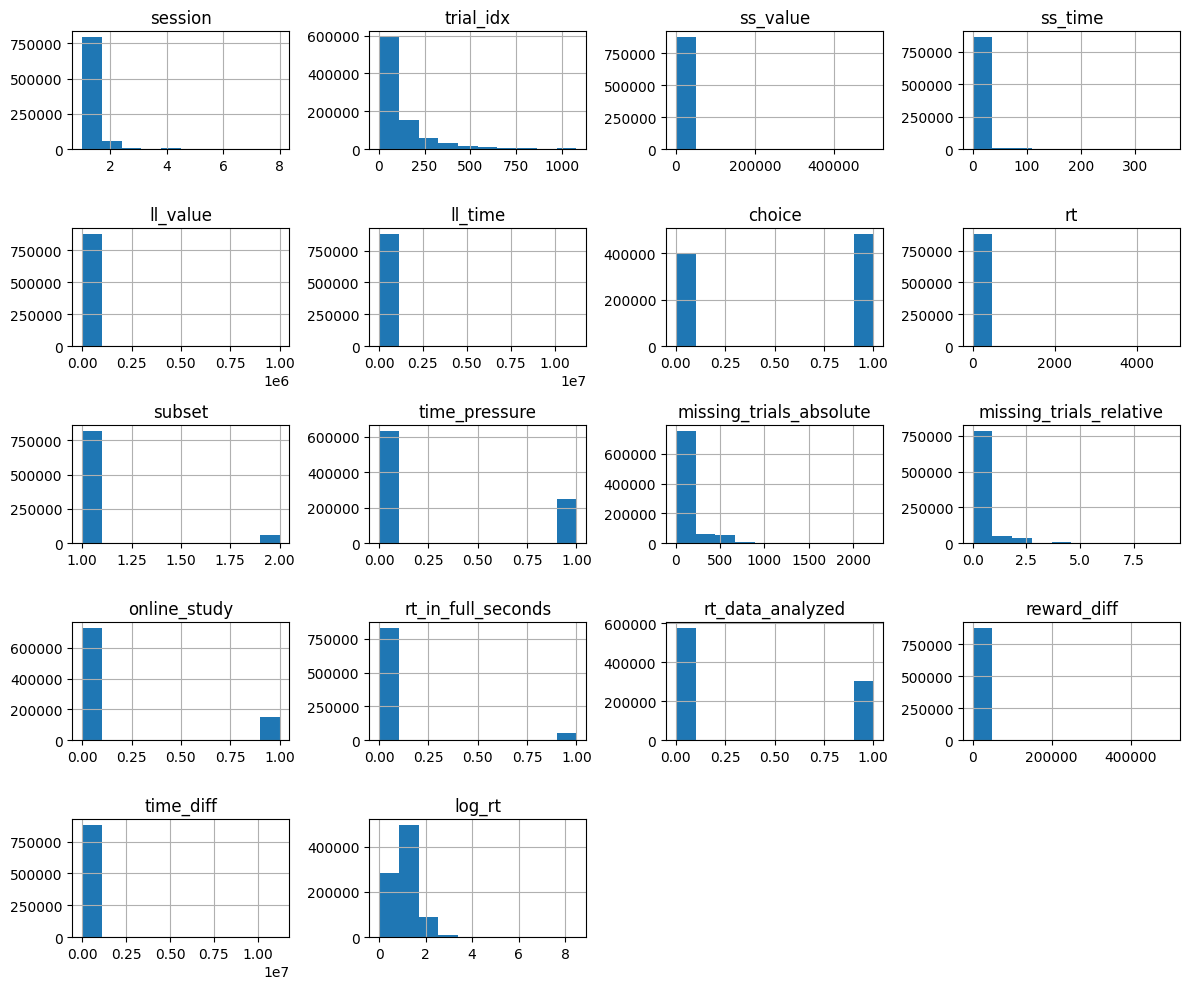

In [ ]:
# --- distribution plot
import matplotlib.pyplot as plt
import numpy as np

# numeric columns
num_cols = dfcleaned.select_dtypes(include=np.number).columns

dfcleaned[num_cols].hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

Key Insights:
Heavy Right Skew seen in ss_value, ll_value, ss_time, ll_time, rt (response time)

Most values are small, but few are extremely large.

Implication: Should use median and consider log transformation because

Binary Variables
Choice
Time_pressure
online_study
rt_data_analyzed

These are categorical features. Therefore Logistic Regression should be used as a baseline model.

Age Distribution
Slight right skew
most subjects are bwtween 20 - 40



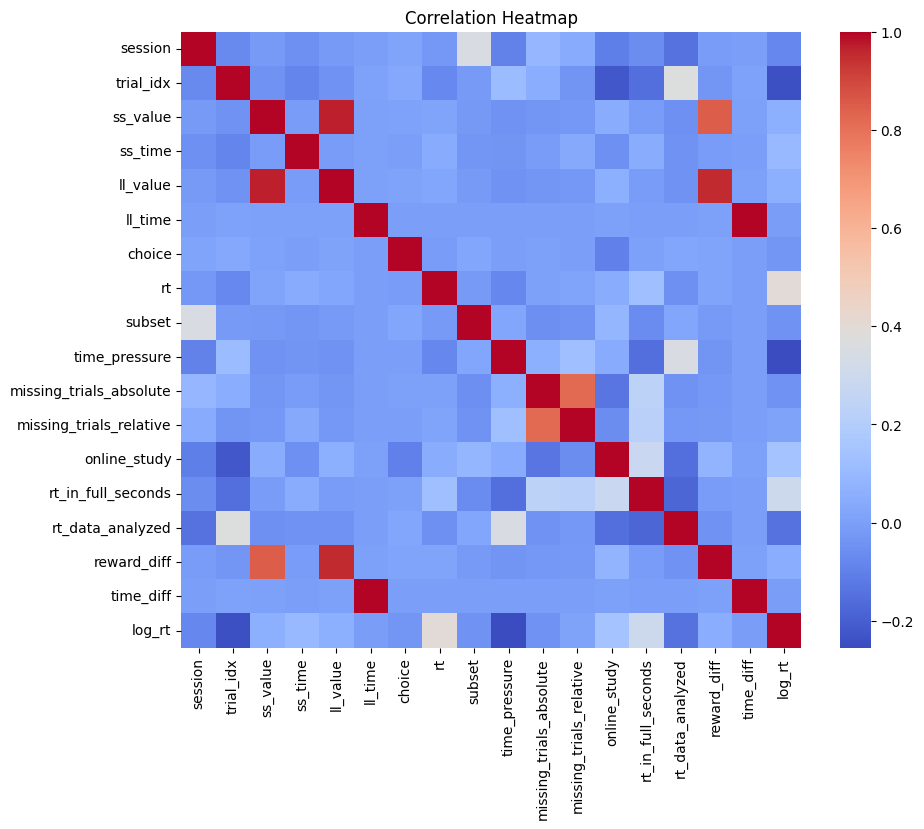

In [ ]:
# --- correlation heatmap
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(dfcleaned[num_cols].corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Key Insights:
Strong positive correlation between reward variables
ss_value and ll_value
Moderate correlation between ss_time and ll_time
Missing data variables are highly correelated missing_trials_absolute and missing_trials_reelative
Strong relationship between time_preessure and time_pressure_cont
Choice is VERY weakly correlated with most variables - this is a huge insight because behaviour is not linearnly explained so it suggests the need for logistic regression


In [ ]:
target = "choice"

df[target].value_counts()

,count
choice,
1,654405
0,518239


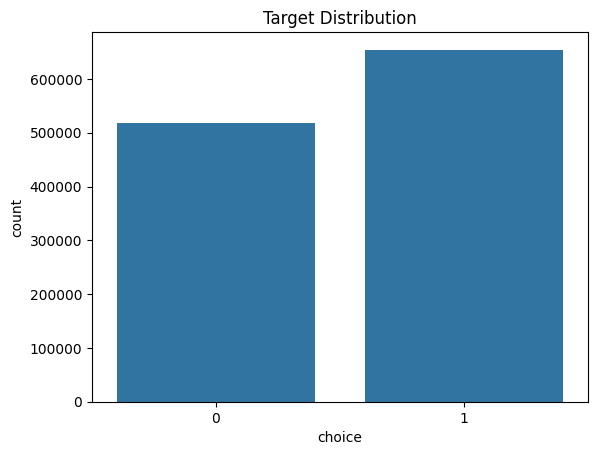

In [ ]:
sns.countplot(x=target, data=df)
plt.title("Target Distribution")
plt.show()

##**Analytical Business Question: Auto Insurance**

How can we predict whether users choose immediate spending vs delayed financial rewards?

What is a potential business application from this analysis?

Tiered pricing in insurance involves segmenting customers into different risk-based categories and offering varying premiums and coverage levels accordingly. Customers are often presented with trade-offs, such as choosing between lower monthly payments with higher long-term costs or higher upfront payments with future savings.

This structure mirrors intertemporal choice behavior, where individuals must decide between immediate costs and delayed financial benefits. By modeling these decisions, companies can optimize pricing tiers, encourage long-term commitments, and better align products with customer preferences.



**Data Modeling**

Logistic Regression Model (Baseline Model)

In [ ]:
# --- Logitistic Regression Model

#select features for the modeling dataset (only what the model needs)

features = [
    "reward_diff",
    "time_diff",
    "log_rt",
    "time_pressure"
]
df_model = dfcleaned[features + ["choice"]]

In [ ]:
# --- Define Data and split it into input and output
X = df_model[features]
# --- choice is our target variable
y = df_model["choice"]

In [ ]:
print(X.shape)

(879977, 4)


In [ ]:
print(X.isnull().sum())

reward_diff      0
time_diff        0
log_rt           0
time_pressure    0
dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# --- scale features

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
# --- Train logistic regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train_scaled, y_train)

LogisticRegression()

In [ ]:
# --- Make Predictions
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled) [:, 1]


In [ ]:
# --- Evaluate Model
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

Accuracy: 0.5506716061728676
AUC: 0.5284014442093413
              precision    recall  f1-score   support

           0       0.49      0.01      0.03     79028
           1       0.55      0.99      0.71     96968

    accuracy                           0.55    175996
   macro avg       0.52      0.50      0.37    175996
weighted avg       0.52      0.55      0.40    175996



In [ ]:
# --- Interpret
import pandas as pd

coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_[0]
})

print(coefficients)

         Feature  Coefficient
0    reward_diff     0.046038
1      time_diff    -0.160712
2         log_rt    -0.074901
3  time_pressure    -0.018827


Random Forest (Advanced Model)

In [88]:
#create behavioral features

dfcleaned['value_ratio'] = dfcleaned['ll_value'] / (dfcleaned['ss_value'] + 1e-5)
dfcleaned['discount_proxy'] = dfcleaned['reward_diff'] / (dfcleaned['time_diff'] + 1e-5)

In [89]:
num_features = [
    'ss_value', 'ss_time', 'll_value', 'll_time',
    'reward_diff', 'time_diff', 'value_ratio', 'discount_proxy',
    'rt'
]
cat_features = [
    'country', 'currency', 'procedure',
    'incentivization', 'presentation_of_information'
]

In [ ]:
#Encode Categorical Variables
df_model = pd.get_dummies(dfcleaned[num_features + cat_features + ['choice']], drop_first=True)

In [ ]:
#train-test split
from sklearn.model_selection import train_test_split

X = df_model.drop('choice', axis=1)
y = df_model['choice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#train the model

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_jobs=-1, random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))